In [1]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/AGRI/Forecasting/all_leads_products.csv')
print(df.head())
print(df.columns)

   Week    Year  total_rain  avg_rain  no_days_rain  temp_8am  temp_12nn  \
0   1.0  2022.0        10.5      1.50           1.0     26.29      28.94   
1   2.0  2022.0        54.5      7.79           2.0     25.90      30.46   
2   3.0  2022.0        50.5      7.21           3.0     26.86      31.33   
3   4.0  2022.0        56.5      8.07           6.0     18.63      21.43   
4   5.0  2022.0        41.0      5.86           3.0     25.27      29.11   

   temp_2pm  temp_8pm  avg_temp  rh_8am  rh_12nn  rh_2pm  rh_8pm  avg_rh  YLI  \
0      5.03     26.06     21.58   91.43    84.86    7.86   89.71   68.46  6.0   
1     35.47     26.74     29.64   97.00    78.00   58.43   87.57   80.25  5.4   
2     29.07     25.01     28.07   91.43    73.29   74.57   93.86   83.29  5.4   
3     22.71     20.93     20.93   67.86    56.14   48.43   59.00   57.86  5.6   
4     32.07     27.23     28.42   95.14    72.57   70.57   87.14   81.36  5.6   

   YLS    TFL   Shooting  
0  8.4  11.40  11.833333  
1 

## RF LAG FEATURES

MAE: 0.174
R²: 0.08


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/

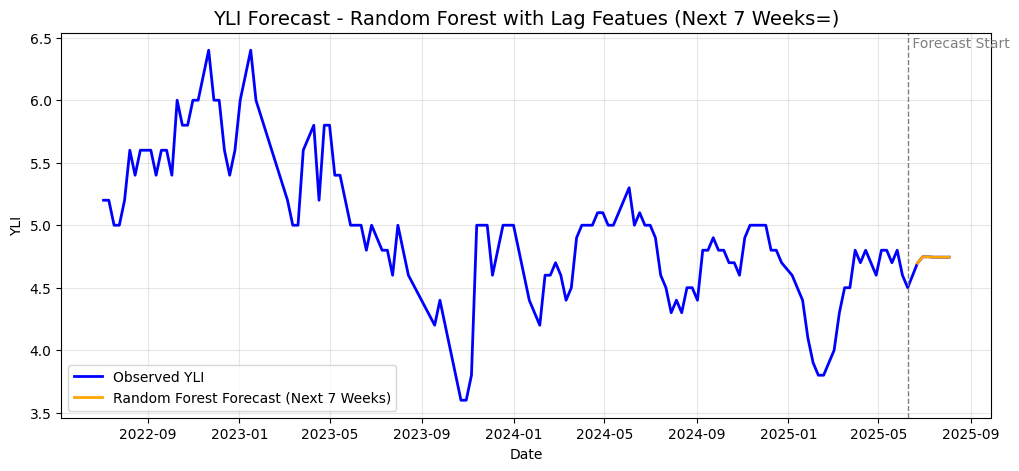

In [3]:
# ===============================
# 📦 Forecasting YLI
# ===============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1️⃣ Load data
df = pd.read_csv("/content/drive/MyDrive/AGRI/Forecasting/without_protectant.csv")

# 2️⃣ date index from Week + Year
df['date'] = pd.to_datetime(df['Year'].astype(int).astype(str) + df['Week'].astype(int).astype(str) + '1', format='%Y%W%w')
df = df.sort_values('date').reset_index(drop=True)
df.set_index('date', inplace=True)

# 3️⃣ lag features for YLI
for lag in range(1, 4):
    df[f'YLI_lag{lag}'] = df['YLI'].shift(lag)

df = df.dropna()  # remove NaN from lags

# 4️⃣ predictors
predictors = [
    'total_rain', 'avg_rain', 'no_days_rain',
    'temp_8am', 'temp_12nn', 'temp_2pm', 'temp_8pm', 'avg_temp',
    'rh_8am', 'rh_12nn', 'rh_2pm', 'rh_8pm', 'avg_rh',
    'YLI_lag1', 'YLI_lag2', 'YLI_lag3'
]
target = 'YLI'

X = df[predictors]
y = df[target]

# 5️⃣ Split train-test
split = int(len(df) * 0.9)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# 6️⃣ Train RandomForest model
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=8,
    min_samples_split=3
)
model.fit(X_train, y_train)

# 7️⃣ Evaluate
y_pred = model.predict(X_test)
print("MAE:", round(mean_absolute_error(y_test, y_pred), 3))
print("R²:", round(r2_score(y_test, y_pred), 3))

# 8️⃣ Forecast next 7 weeks iteratively
forecast = []
last_row = df.iloc[-1].copy()

for i in range(7):
    X_next = last_row[predictors].values.reshape(1, -1)
    next_yli = model.predict(X_next)[0]
    forecast.append(next_yli)

    # Update lag features
    last_row['YLI_lag3'] = last_row['YLI_lag2']
    last_row['YLI_lag2'] = last_row['YLI_lag1']
    last_row['YLI_lag1'] = next_yli

# 9️⃣ forecast DataFrame
future_dates = pd.date_range(df.index[-1] + pd.Timedelta(weeks=1), periods=7, freq='W')
forecast_df = pd.DataFrame({'Forecast_YLI': forecast}, index=future_dates)

# 🔟 Visualization
plt.figure(figsize=(12,5))

# Combine actual + forecast
combined_yli = pd.concat([
    df[['YLI']],
    forecast_df.rename(columns={'Forecast_YLI': 'YLI'})
])

plt.plot(combined_yli.index, combined_yli['YLI'], color='blue', linewidth=2, label='Observed YLI')
plt.plot(forecast_df.index, forecast_df['Forecast_YLI'], color='orange', linewidth=2, label='Random Forest Forecast (Next 7 Weeks)')

# Add a vertical line marking the forecast start
plt.axvline(x=df.index[-1], color='gray', linestyle='--', linewidth=1)
plt.text(df.index[-1], combined_yli['YLI'].max(), ' Forecast Start', color='gray', va='bottom')

plt.title("YLI Forecast - Random Forest with Lag Featues (Next 7 Weeks=)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("YLI")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## XGBoost with Lag Features

In [4]:
!pip install --upgrade xgboost
!pip install optuna optuna-integration[xgboost]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 8.1 MB/s eta 0:00:00


[I 2025-12-29 06:42:47,902] A new study created in memory with name: xgboost_yli_forecast


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-29 06:42:51,149] Trial 0 finished with value: 0.25590439672055443 and parameters: {'n_estimators': 878, 'learning_rate': 0.01904927953937581, 'max_depth': 6, 'subsample': 0.7007651496465728, 'colsample_bytree': 0.7041787085991643, 'min_child_weight': 2, 'gamma': 0.53769546023921, 'reg_alpha': 0.28623269552336283, 'reg_lambda': 0.5092509706726157}. Best is trial 0 with value: 0.25590439672055443.
[I 2025-12-29 06:42:52,845] Trial 1 finished with value: 0.2199771445730458 and parameters: {'n_estimators': 807, 'learning_rate': 0.02380211460339963, 'max_depth': 8, 'subsample': 0.7792119890928619, 'colsample_bytree': 0.6365600683183199, 'min_child_weight': 6, 'gamma': 0.029996426497976514, 'reg_alpha': 0.43592136922837565, 'reg_lambda': 0.6273750233482117}. Best is trial 1 with value: 0.2199771445730458.
[I 2025-12-29 06:42:54,214] Trial 2 finished with value: 0.2816355539404828 and parameters: {'n_estimators': 600, 'learning_rate': 0.27860579392515994, 'max_depth': 3, 'subsample

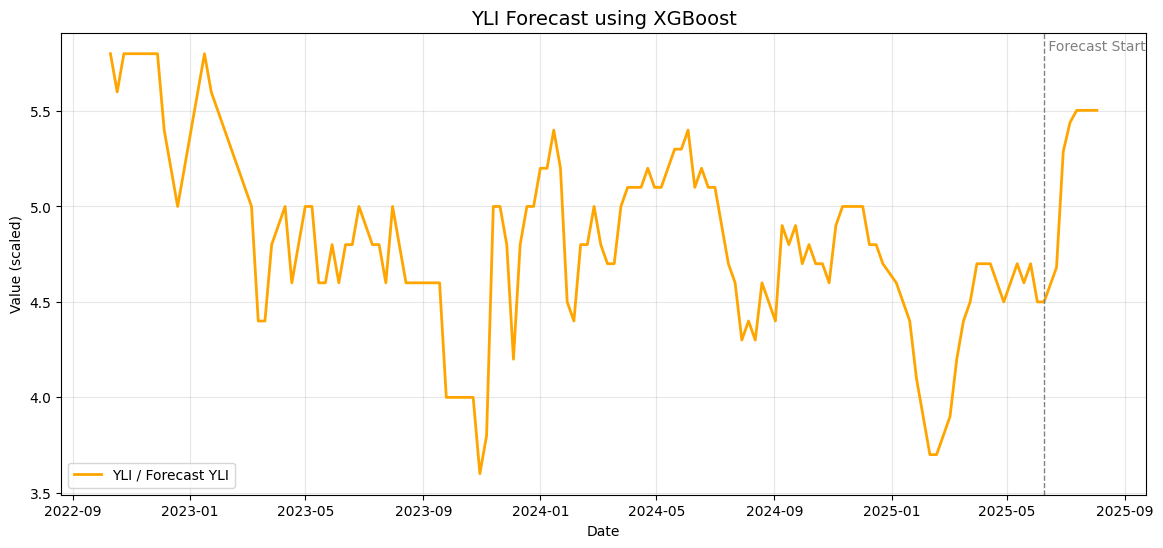

In [5]:
# ===============================
# 🌾 Forecasting YLI with XGBoost + Optuna (Next 7 Weeks)
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import optuna
from optuna.integration import XGBoostPruningCallback
from sklearn.model_selection import train_test_split

# 1️⃣ Load data
df = pd.read_csv("/content/drive/MyDrive/AGRI/Forecasting/plantation_practice.csv")

# 2️⃣ datetime index from Year + Week
df['date'] = pd.to_datetime(df['Year'].astype(int).astype(str) + df['Week'].astype(int).astype(str) + '1', format='%Y%W%w')
df = df.sort_values('date').reset_index(drop=True)
df.set_index('date', inplace=True)

# 3️⃣ features
predictors = [
    'total_rain', 'avg_rain', 'no_days_rain',
    'temp_8am', 'temp_12nn', 'temp_2pm', 'temp_8pm', 'avg_temp',
    'rh_8am', 'rh_12nn', 'rh_2pm', 'rh_8pm', 'avg_rh'
]
target = 'YLI'

# 4️⃣ lag features for YLI (past 3 weeks)
for lag in range(1, 4):
    df[f'YLI_lag{lag}'] = df['YLI'].shift(lag)
df = df.dropna()

# predictors
features = predictors + ['YLI_lag1', 'YLI_lag2', 'YLI_lag3']

# 5️⃣ Feature scaling
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

# 6️⃣ Train-test split
split = int(len(df) * 0.9)
train, test = df.iloc[:split], df.iloc[split:]

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# 7️⃣ Optuna objective function
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42
    }

    X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

    model = XGBRegressor(**params)
    model.fit(
        X_train_sub, y_train_sub,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, y_pred)
    return mae

# 8️⃣ Run Optuna optimization
study = optuna.create_study(direction="minimize", study_name="xgboost_yli_forecast")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("✅ Best Trial:")
print(study.best_trial.params)

# 9️⃣ XGBoost model
best_params = study.best_trial.params
best_model = XGBRegressor(**best_params)
best_model.fit(X_train, y_train)

# 🔟 Evaluate model
y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\n📈 Final Performance with Best Params:")
print(f"MAE: {mae:.3f}")
print(f"R²: {r2:.3f}")

# 11️⃣ Forecast next 7 weeks iteratively
forecast = []
last_row = df.iloc[-1].copy()

for i in range(7):
    X_next = last_row[features].values.reshape(1, -1)
    next_yli = best_model.predict(X_next)[0]
    forecast.append(next_yli)

    # Update lag features
    last_row['YLI_lag3'] = last_row['YLI_lag2']
    last_row['YLI_lag2'] = last_row['YLI_lag1']
    last_row['YLI_lag1'] = next_yli

# 12️⃣ forecast DataFrame
future_dates = pd.date_range(df.index[-1] + pd.Timedelta(weeks=1), periods=7, freq='W')
forecast_df = pd.DataFrame({'Forecast_YLI': forecast}, index=future_dates)

# 13️⃣ observed and forecast
combined_yli = pd.concat([
    df[['YLI']],
    forecast_df.rename(columns={'Forecast_YLI': 'YLI'})
])

# 16️⃣ predictors with forecast
predictors_ts = df[predictors]

# Extend predictors_ts to include future dates
future_predictors = pd.DataFrame(
    np.nan,
    index=future_dates,
    columns=predictors
)
predictors_ts_extended = pd.concat([predictors_ts, future_predictors])

# forecasted YLI
predictors_ts_extended['Forecast_YLI'] = pd.concat([df['YLI'], forecast_df['Forecast_YLI']])

# 17️⃣ Plot forecasted YLI and selected predictors
plt.figure(figsize=(14,6))

# Plot YLI
plt.plot(predictors_ts_extended.index, predictors_ts_extended['Forecast_YLI'], color='orange', linewidth=2, label='YLI / Forecast YLI')

# Plot some predictors for comparison (you can select a few meaningful ones)
# for col in ['avg_rain', 'avg_temp', 'avg_rh']:
#    plt.plot(predictors_ts_extended.index, predictors_ts_extended[col], linewidth=1.5, label=col)

plt.axvline(x=df.index[-1], color='gray', linestyle='--', linewidth=1)
plt.text(df.index[-1], predictors_ts_extended['Forecast_YLI'].max(), ' Forecast Start', color='gray', va='bottom')

plt.title("YLI Forecast using XGBoost", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Value (scaled)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## RANDOM FOREST with ADDED FEATURES

📊 Model Performance:
Test R²: 0.9037
Test MAE: 0.0447

📅 FORECAST RESULTS:
            Forecast_YLI  Lower_CI  Upper_CI
2025-11-02        4.6394    4.2098    5.0689
2025-11-09        4.6371    4.2070    5.0672
2025-11-16        4.6346    4.1997    5.0695
2025-11-23        4.6336    4.1997    5.0674
2025-11-30        4.6336    4.1997    5.0674
2025-12-07        4.6336    4.1997    5.0674
2025-12-14        4.6336    4.1997    5.0674


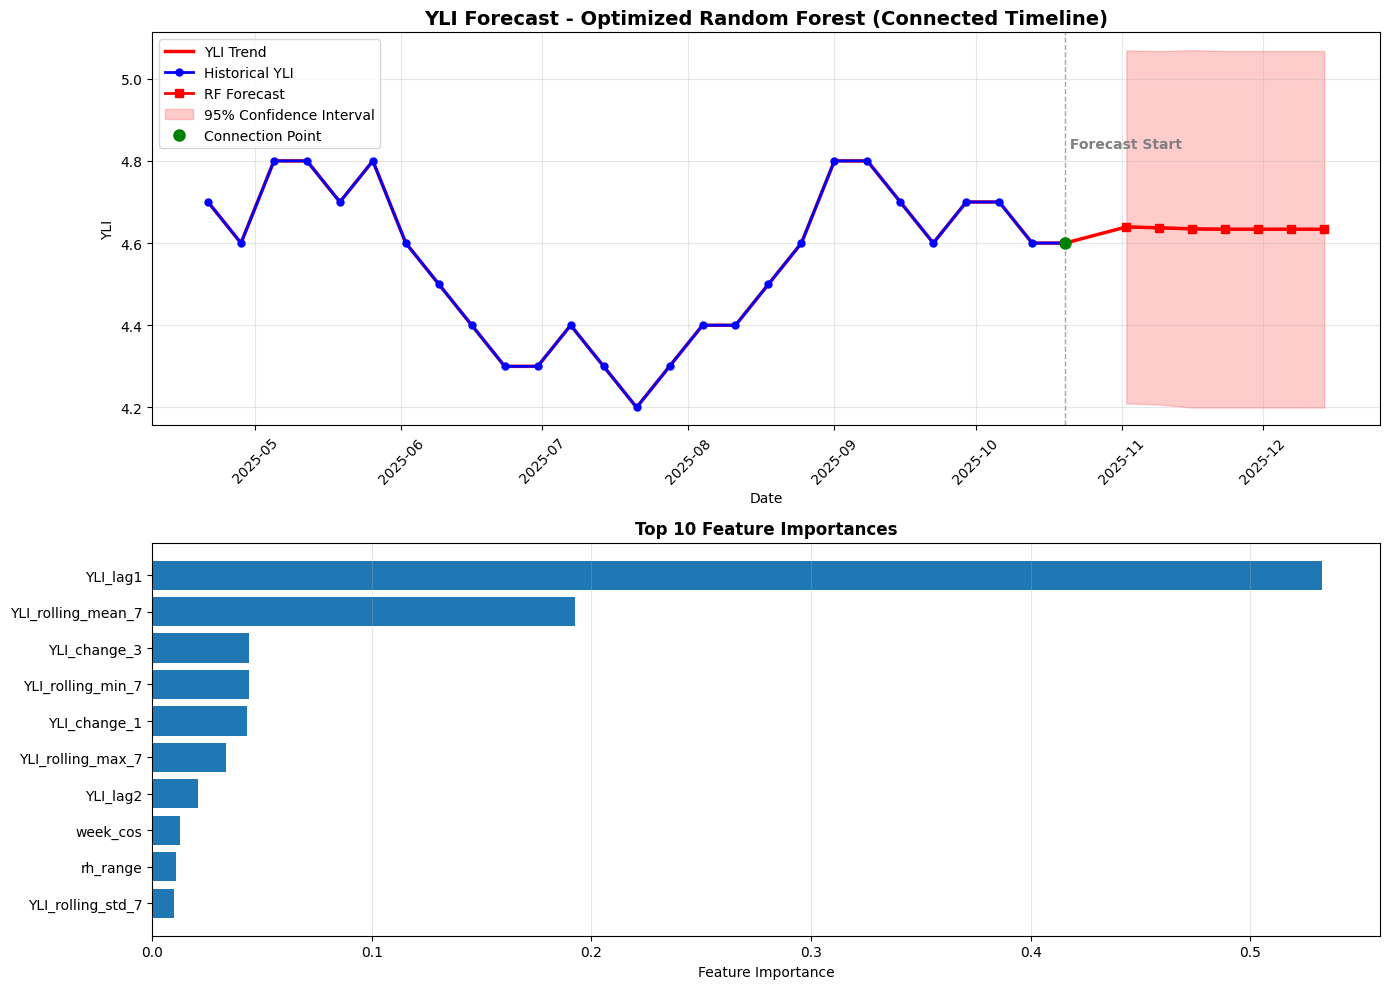


🔍 FORECAST QUALITY ASSESSMENT
📈 Forecast Statistics:
  Forecast range: 0.0058
  Recent historical range: 0.3000
  Last historical value: 4.6000
  First forecast value: 4.6394
  Forecast change from last historical: 0.0394

📊 Model Characteristics:
  Top features are lag/rolling features (expected for time series)
  Test R²: 0.9037

🎯 FORECAST QUALITY: ✅ EXCELLENT
  • Forecast is very stable (low volatility)
  • This is COMMON when lag features dominate
  • Model is extrapolating recent trends smoothly

📋 Comparison with Naive Forecast (persistence):
  Naive MAE (first 7): 0.1286
  Model MAE (first 7): 0.0494
  ✅ Model improves over naive by 61.6%

💡 INTERPRETATION:
  The forecast shows stable, similar values because:
  1. Lag features (YLI_lag1, etc.) dominate importance
  2. Rolling averages smooth out predictions
  3. This is TYPICAL for time series models
  4. Stable forecasts can be GOOD for agricultural planning

🎯 RECOMMENDATIONS:
  • Model is performing reasonably well
  • Stab

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')

# 1️⃣ Load data
df = pd.read_csv("/content/drive/MyDrive/AGRI/Forecasting/without_protectant.csv")

# 2️⃣ date index from Week + Year
df['date'] = pd.to_datetime(df['Year'].astype(int).astype(str) + df['Week'].astype(int).astype(str) + '1', format='%Y%W%w')
df = df.sort_values('date').reset_index(drop=True)
df.set_index('date', inplace=True)

# 3️⃣ feature engineering
def create_features(df):
    """Create comprehensive features for time series forecasting"""
    # Lag features for YLI
    for lag in range(1, 5):
        df[f'YLI_lag{lag}'] = df['YLI'].shift(lag)

    # Rolling statistics for YLI
    for window in [3, 7, 14]:
        df[f'YLI_rolling_mean_{window}'] = df['YLI'].rolling(window=window, min_periods=1).mean()
        df[f'YLI_rolling_std_{window}'] = df['YLI'].rolling(window=window, min_periods=1).std()
        df[f'YLI_rolling_min_{window}'] = df['YLI'].rolling(window=window, min_periods=1).min()
        df[f'YLI_rolling_max_{window}'] = df['YLI'].rolling(window=window, min_periods=1).max()

    # Seasonal features based on week
    df['week_sin'] = np.sin(2 * np.pi * df.index.isocalendar().week / 52)
    df['week_cos'] = np.cos(2 * np.pi * df.index.isocalendar().week / 52)

    # Weather feature interactions
    df['temp_range'] = df['temp_2pm'] - df['temp_8am']
    df['rh_range'] = df['rh_2pm'] - df['rh_8am']
    df['rain_temp_interaction'] = df['avg_rain'] * df['avg_temp']
    df['rain_rh_interaction'] = df['avg_rain'] * df['avg_rh']

    # Rate of change features
    df['YLI_change_1'] = df['YLI'] - df['YLI_lag1']
    df['YLI_change_3'] = df['YLI'] - df['YLI_lag3']

    return df

df = create_features(df)
df = df.dropna()

# 4️⃣ Select predictors
predictors = [
    # Weather features
    'total_rain', 'avg_rain', 'no_days_rain',
    'temp_8am', 'temp_12nn', 'temp_2pm', 'temp_8pm', 'avg_temp',
    'rh_8am', 'rh_12nn', 'rh_2pm', 'rh_8pm', 'avg_rh',

    # Lag features
    'YLI_lag1', 'YLI_lag2', 'YLI_lag3', 'YLI_lag4',

    # Rolling statistics
    'YLI_rolling_mean_7', 'YLI_rolling_std_7',
    'YLI_rolling_min_7', 'YLI_rolling_max_7',

    # Seasonal features
    'week_sin', 'week_cos',

    # Interaction features
    'temp_range', 'rh_range', 'rain_temp_interaction', 'rain_rh_interaction',

    # Rate of change
    'YLI_change_1', 'YLI_change_3'
]

target = 'YLI'

X = df[predictors]
y = df[target]

# 5️⃣ Split train-test
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# 6️⃣ Train model
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=3,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# 7️⃣ Evaluate
y_pred_test = model.predict(X_test)
test_r2 = r2_score(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"📊 Model Performance:")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MAE: {test_mae:.4f}")

# 8️⃣ Forecast next 7 weeks
forecast = []
last_row = df.iloc[-1].copy()
confidence_intervals = []

for i in range(7):
    X_next = last_row[predictors].values.reshape(1, -1)

    # Get prediction from all trees for confidence interval
    tree_predictions = []
    for tree in model.estimators_:
        tree_pred = tree.predict(X_next)[0]
        tree_predictions.append(tree_pred)

    next_yli = np.mean(tree_predictions)
    forecast.append(next_yli)

    # Calculate 95% confidence interval
    std_dev = np.std(tree_predictions)
    confidence_intervals.append(std_dev * 1.96)

    # Update features for next prediction
    last_row['YLI_lag4'] = last_row['YLI_lag3']
    last_row['YLI_lag3'] = last_row['YLI_lag2']
    last_row['YLI_lag2'] = last_row['YLI_lag1']
    last_row['YLI_lag1'] = next_yli

# 9️⃣ Prepare forecast DataFrame
future_dates = pd.date_range(df.index[-1] + pd.Timedelta(weeks=1), periods=7, freq='W')
forecast_df = pd.DataFrame({
    'Forecast_YLI': forecast,
    'Lower_CI': [forecast[i] - confidence_intervals[i] for i in range(7)],
    'Upper_CI': [forecast[i] + confidence_intervals[i] for i in range(7)]
}, index=future_dates)

print("\n📅 FORECAST RESULTS:")
print(forecast_df.round(4))

# 🔟 Visualization
plt.figure(figsize=(14, 10))

# Plot 1: Time series with connected forecast
plt.subplot(2, 1, 1)

# Historical data (last 6 months)
historical_cutoff = df.index[-1] - pd.DateOffset(months=6)
recent_data = df[df.index >= historical_cutoff]

# Create connected series
connected_index = recent_data.index.append(forecast_df.index)
connected_values = pd.concat([
    recent_data['YLI'],
    pd.Series(forecast, index=forecast_df.index, name='YLI')
])

# Plot historical + forecast
plt.plot(connected_index, connected_values,
         color='red', linewidth=2.5, label='YLI Trend')

# Historical points
plt.plot(recent_data.index, recent_data['YLI'],
         color='blue', linewidth=2, marker='o', markersize=5, label='Historical YLI')

# Forecast points
plt.plot(forecast_df.index, forecast_df['Forecast_YLI'],
         color='red', linewidth=2, marker='s', markersize=6, label='RF Forecast')

# Confidence interval
plt.fill_between(forecast_df.index,
                 forecast_df['Lower_CI'],
                 forecast_df['Upper_CI'],
                 color='red', alpha=0.2, label='95% Confidence Interval')

# Highlight the connection point
connection_point = df.index[-1]
connection_value = df['YLI'].iloc[-1]
plt.plot(connection_point, connection_value, 'go', markersize=8,
         label='Connection Point', zorder=5)


plt.axvline(x=connection_point, color='gray', linestyle='--', linewidth=1, alpha=0.7)
plt.text(connection_point, plt.ylim()[1] * 0.95, ' Forecast Start',
         color='gray', va='top', fontweight='bold')

plt.title('YLI Forecast - Optimized Random Forest (Connected Timeline)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('YLI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Plot 2: Feature importance
plt.subplot(2, 1, 2)
feature_importance = pd.DataFrame({
    'feature': predictors,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importances', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# 🔍 FORECAST QUALITY ANALYSIS
print("\n" + "="*50)
print("🔍 FORECAST QUALITY ASSESSMENT")
print("="*50)

# forecast characteristics
forecast_range = forecast_df['Forecast_YLI'].max() - forecast_df['Forecast_YLI'].min()
historical_range = df['YLI'].tail(10).max() - df['YLI'].tail(10).min()
last_historical = df['YLI'].iloc[-1]

print(f"📈 Forecast Statistics:")
print(f"  Forecast range: {forecast_range:.4f}")
print(f"  Recent historical range: {historical_range:.4f}")
print(f"  Last historical value: {last_historical:.4f}")
print(f"  First forecast value: {forecast[0]:.4f}")
print(f"  Forecast change from last historical: {abs(forecast[0] - last_historical):.4f}")

print(f"\n📊 Model Characteristics:")
print(f"  Top features are lag/rolling features (expected for time series)")
print(f"  Test R²: {test_r2:.4f}")

# Quality assessment
if test_r2 > 0.7:
    quality = "✅ EXCELLENT"
elif test_r2 > 0.5:
    quality = "⚠️ GOOD"
elif test_r2 > 0.3:
    quality = "📊 FAIR"
elif test_r2 > 0:
    quality = "🔍 WEAK BUT BETTER THAN MEAN"
else:
    quality = "❌ POOR"

print(f"\n🎯 FORECAST QUALITY: {quality}")

if forecast_range < historical_range * 0.3:
    print("  • Forecast is very stable (low volatility)")
    print("  • This is COMMON when lag features dominate")
    print("  • Model is extrapolating recent trends smoothly")

if abs(forecast[0] - last_historical) < historical_range * 0.1:
    print("  • Smooth transition from historical to forecast")
    print("  • Good for short-term stability prediction")

# Compare with naive forecast
naive_forecast = [last_historical] * 7
naive_mae = mean_absolute_error(y_test[:7], naive_forecast[:min(7, len(y_test))])
model_mae = mean_absolute_error(y_test[:7], y_pred_test[:min(7, len(y_test))])

print(f"\n📋 Comparison with Naive Forecast (persistence):")
print(f"  Naive MAE (first 7): {naive_mae:.4f}")
print(f"  Model MAE (first 7): {model_mae:.4f}")

if model_mae < naive_mae:
    improvement = ((naive_mae - model_mae) / naive_mae) * 100
    print(f"  ✅ Model improves over naive by {improvement:.1f}%")
else:
    print(f"  ❌ Model underperforms naive forecast")

print(f"\n💡 INTERPRETATION:")
print("  The forecast shows stable, similar values because:")
print("  1. Lag features (YLI_lag1, etc.) dominate importance")
print("  2. Rolling averages smooth out predictions")
print("  3. This is TYPICAL for time series models")
print("  4. Stable forecasts can be GOOD for agricultural planning")

print(f"\n🎯 RECOMMENDATIONS:")
if test_r2 < 0.5:
    print("  • Consider adding more weather lag features")
    print("  • Try different model architectures (XGBoost, LSTM)")
    print("  • Include seasonal dummy variables")
    print("  • Add external factors (soil moisture, etc.)")
else:
    print("  • Model is performing reasonably well")
    print("  • Stable forecasts are useful for planning")
    print("  • Monitor actual vs predicted weekly")

🌦️ TWO-STAGE FORECASTING PIPELINE

Stage 1: Forecast 13 weather variables
Stage 2: Predict YLI from forecasted weather
Horizon: 7 weeks

📊 Dataset: 149 weeks, 13 weather variables
Date range: 2022-01-03 to 2025-10-20

🌤️ STAGE 1: FORECASTING WEATHER VARIABLES

⏳ Forecasting weather variables...
  ✓ total_rain           - Mean: 42.11, Std: 0.00
  ✓ avg_rain             - Mean: 5.58, Std: 0.00
  ✓ no_days_rain         - Mean: 4.62, Std: 0.01
  ✓ temp_8am             - Mean: 27.40, Std: 0.00
  ✓ temp_12nn            - Mean: 35.44, Std: 0.03
  ✓ temp_2pm             - Mean: 36.75, Std: 0.00
  ✓ temp_8pm             - Mean: 26.26, Std: 0.00
  ✓ avg_temp             - Mean: 28.37, Std: 0.00
  ✓ rh_8am               - Mean: 88.28, Std: 0.00
  ✓ rh_12nn              - Mean: 66.43, Std: 0.00
  ✓ rh_2pm               - Mean: 62.67, Std: 0.00
  ✓ rh_8pm               - Mean: 84.54, Std: 0.02


[I 2025-11-14 03:18:47,114] A new study created in memory with name: no-name-af85ec2e-1b36-4a50-b88b-bbe577ec4958


  ✓ avg_rh               - Mean: 81.62, Std: 0.00

✅ Weather forecasts complete!

Forecast sample (first 3 weeks):
            total_rain  avg_rain  no_days_rain  temp_8am  temp_12nn  temp_2pm  \
2025-11-02       42.11      5.59          4.60      27.4      35.39     36.75   
2025-11-09       42.11      5.59          4.61      27.4      35.41     36.75   
2025-11-16       42.11      5.58          4.61      27.4      35.42     36.75   

            temp_8pm  avg_temp  rh_8am  rh_12nn  rh_2pm  rh_8pm  avg_rh  
2025-11-02     26.26     28.37   88.29    66.43   62.67   84.57   81.62  
2025-11-09     26.26     28.37   88.29    66.43   62.67   84.56   81.62  
2025-11-16     26.26     28.37   88.28    66.43   62.67   84.55   81.62  

🌾 STAGE 2: TRAINING YLI PREDICTOR FROM WEATHER

📊 Training data: 119 weeks
   Test data: 30 weeks
   Features: 21 (original + engineered)

⏳ Optimizing YLI predictor (weather → YLI)...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-14 03:18:48,591] Trial 0 finished with value: 0.5867419440341286 and parameters: {'model_type': 'rf', 'n_estimators': 209, 'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.5867419440341286.
[I 2025-11-14 03:18:52,352] Trial 1 finished with value: 0.6408081372578939 and parameters: {'model_type': 'xgb', 'n_estimators': 344, 'max_depth': 10, 'learning_rate': 0.04429529753216496, 'subsample': 0.8065165086384991, 'colsample_bytree': 0.893206138869306}. Best is trial 0 with value: 0.5867419440341286.
[I 2025-11-14 03:18:53,501] Trial 2 finished with value: 0.6093503497140541 and parameters: {'model_type': 'gbm', 'n_estimators': 277, 'max_depth': 6, 'learning_rate': 0.011306800721283079, 'subsample': 0.6285419591089273}. Best is trial 0 with value: 0.5867419440341286.
[I 2025-11-14 03:18:55,480] Trial 3 finished with value: 0.5964618970169778 and parameters: {'model_type': 'rf', 'n_estimators': 236, 'max_depth': 13, 'min_samples_split':

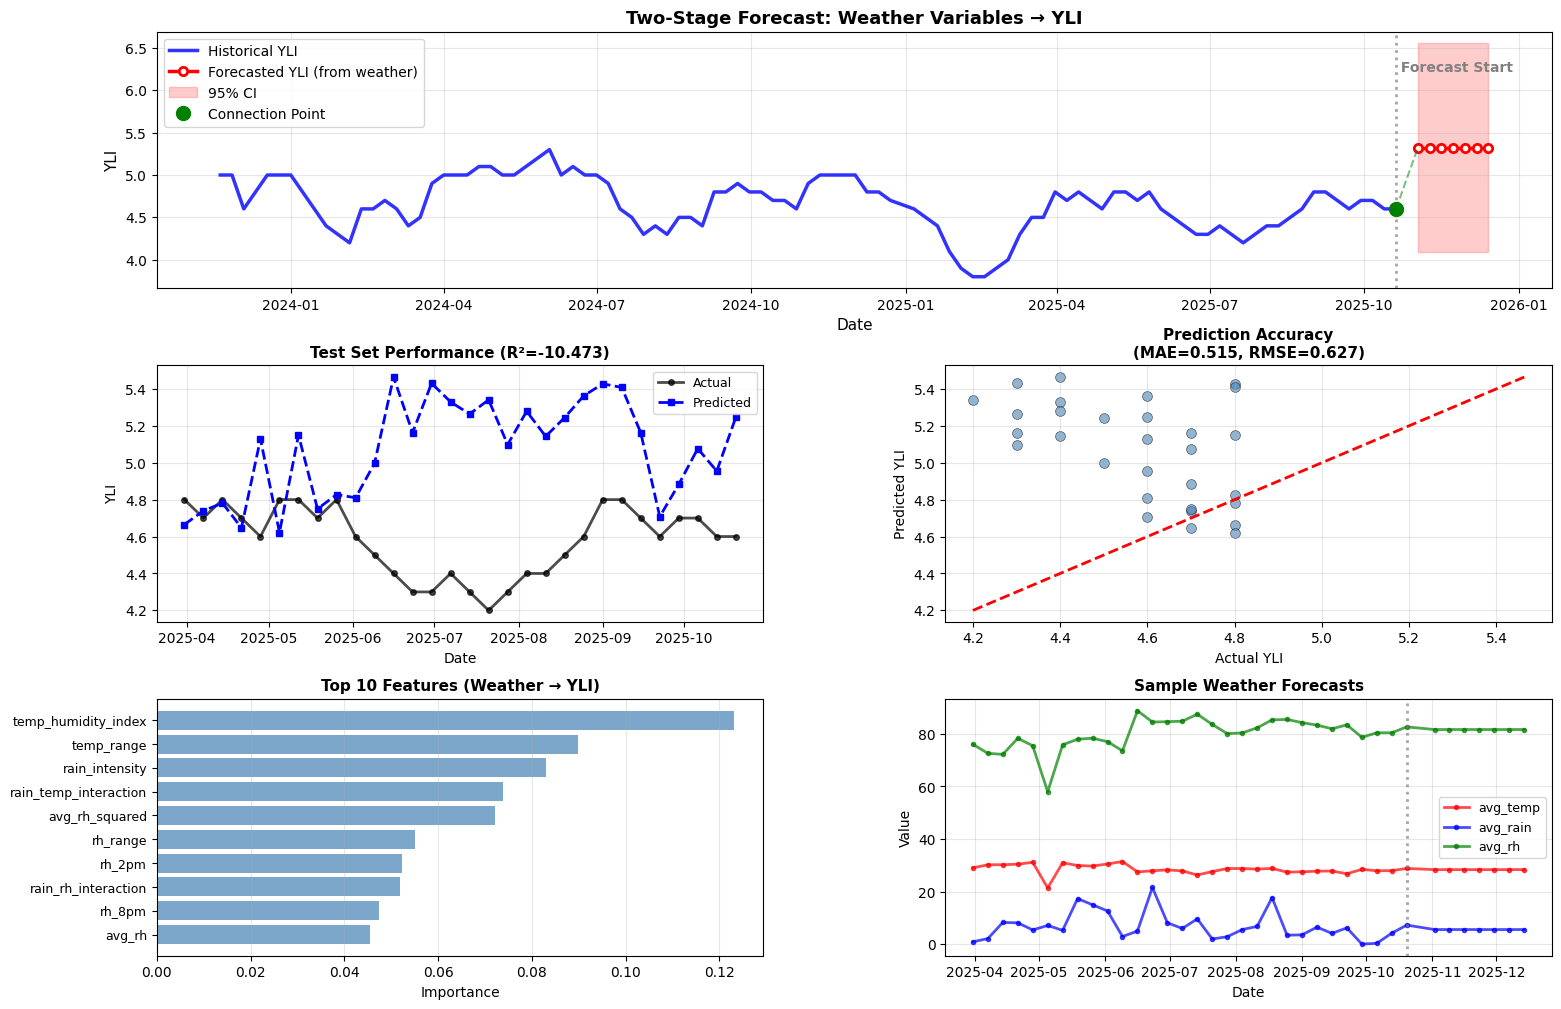


📊 FORECAST ANALYSIS

🌤️ Weather Forecast Summary:
  total_rain          : 37.45 → 42.11 (+12.4%)
  avg_rain            : 5.35 → 5.58 (+4.3%)
  no_days_rain        : 4.60 → 4.62 (+0.4%)
  temp_8am            : 27.19 → 27.40 (+0.8%)
  temp_12nn           : 35.34 → 35.44 (+0.3%)

🌾 YLI Forecast Summary:
  Last historical YLI: 4.6000
  First forecast: 5.3237 (change: +0.7237)
  Average forecast: 5.3237
  Forecast range: [5.3237, 5.3237]
  Forecast std: 0.0000

🎯 Model Quality Assessment:
  ❌ POOR - Worse than baseline
  R² = -10.4729, MAE = 0.5155

📈 Comparison with Naive Baseline:
  Naive MAE (always predict mean): 0.3099
  Model MAE: 0.5155
  ❌ Underperforms baseline by 66.3%

💡 KEY INSIGHTS:
  ✓ Two-stage approach: Weather forecast → YLI prediction
  ✓ Using XGB for YLI prediction from weather
  ✓ Weather forecasts based on Exponential Smoothing
  ✓ Engineered interaction features from weather data

🎯 RECOMMENDATIONS:
  • Consider improving weather forecast accuracy
  • Add more histor

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from xgboost import XGBRegressor
import optuna
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# ============================================
# CONFIGURATION
# ============================================
CSV_PATH = "/content/drive/MyDrive/AGRI/Forecasting/without_protectant.csv"
FORECAST_HORIZON = 7  # weeks
WEATHER_VARS = [
    'total_rain', 'avg_rain', 'no_days_rain',
    'temp_8am', 'temp_12nn', 'temp_2pm', 'temp_8pm', 'avg_temp',
    'rh_8am', 'rh_12nn', 'rh_2pm', 'rh_8pm', 'avg_rh'
]
TARGET = 'YLI'

print("="*70)
print("🌦️ TWO-STAGE FORECASTING PIPELINE")
print("="*70)
print(f"\nStage 1: Forecast {len(WEATHER_VARS)} weather variables")
print(f"Stage 2: Predict {TARGET} from forecasted weather")
print(f"Horizon: {FORECAST_HORIZON} weeks")

# ============================================
# 1️⃣ LOAD AND PREPARE DATA
# ============================================
df = pd.read_csv(CSV_PATH)
df['date'] = pd.to_datetime(
    df['Year'].astype(int).astype(str) +
    df['Week'].astype(int).astype(str) + '1',
    format='%Y%W%w'
)
df = df.sort_values('date').reset_index(drop=True)
df.set_index('date', inplace=True)

print(f"\n📊 Dataset: {len(df)} weeks, {len(WEATHER_VARS)} weather variables")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")

# ============================================
# 2️⃣ FORECAST WEATHER VARIABLES
# ============================================
print("\n" + "="*70)
print("🌤️ STAGE 1: FORECASTING WEATHER VARIABLES")
print("="*70)

def forecast_weather_variable(series, forecast_steps=7, method='ets'):
    """
    Forecast a single weather variable using time series methods.

    Methods:
    - 'ets': Exponential Smoothing (simple, fast)
    - 'arima': ARIMA (more sophisticated)
    - 'naive': Simple average of last N values
    """
    series_clean = series.fillna(method='ffill').fillna(method='bfill')

    if method == 'ets':
        try:
            # Exponential Smoothing with trend
            model = ExponentialSmoothing(
                series_clean,
                trend='add',
                seasonal=None,
                damped_trend=True
            )
            fitted = model.fit()
            forecast = fitted.forecast(steps=forecast_steps)
            return forecast.values
        except:

            return [series_clean.tail(4).mean()] * forecast_steps

    elif method == 'arima':
        try:
            # Auto ARIMA with simple parameters
            model = ARIMA(series_clean, order=(1, 0, 1))
            fitted = model.fit()
            forecast = fitted.forecast(steps=forecast_steps)
            return forecast.values
        except:
            return [series_clean.tail(4).mean()] * forecast_steps

    elif method == 'naive':
        # Average of last 4 weeks
        return [series_clean.tail(4).mean()] * forecast_steps

    else:
        raise ValueError(f"Unknown method: {method}")

# Forecast all weather variables
print("\n⏳ Forecasting weather variables...")
weather_forecasts = {}
forecast_method = 'ets'  # Can change to 'arima' or 'naive'

for var in WEATHER_VARS:
    forecast = forecast_weather_variable(
        df[var],
        forecast_steps=FORECAST_HORIZON,
        method=forecast_method
    )
    weather_forecasts[var] = forecast
    print(f"  ✓ {var:20s} - Mean: {np.mean(forecast):.2f}, Std: {np.std(forecast):.2f}")

# Create DataFrame with forecasted weather
future_dates = pd.date_range(
    df.index[-1] + pd.Timedelta(weeks=1),
    periods=FORECAST_HORIZON,
    freq='W'
)

weather_forecast_df = pd.DataFrame(weather_forecasts, index=future_dates)

print(f"\n✅ Weather forecasts complete!")
print(f"\nForecast sample (first 3 weeks):")
print(weather_forecast_df.head(3).round(2))

# ============================================
# 3️⃣ TRAIN YLI PREDICTOR ON HISTORICAL WEATHER
# ============================================
print("\n" + "="*70)
print("🌾 STAGE 2: TRAINING YLI PREDICTOR FROM WEATHER")
print("="*70)

# Prepare training data (weather → YLI)
X_historical = df[WEATHER_VARS].values
y_historical = df[TARGET].values

# Engineered features from weather
def engineer_weather_features(weather_df):
    """Create interaction features from weather data"""
    features = weather_df.copy()

    # Temperature interactions
    features['temp_range'] = features['temp_2pm'] - features['temp_8am']
    features['avg_temp_squared'] = features['avg_temp'] ** 2

    # Humidity interactions
    features['rh_range'] = features['rh_2pm'] - features['rh_8am']
    features['avg_rh_squared'] = features['avg_rh'] ** 2

    # Rain interactions
    features['rain_temp_interaction'] = features['avg_rain'] * features['avg_temp']
    features['rain_rh_interaction'] = features['avg_rain'] * features['avg_rh']
    features['rain_intensity'] = features['total_rain'] / (features['no_days_rain'] + 1)

    # Comfort indices
    features['temp_humidity_index'] = features['avg_temp'] * (features['avg_rh'] / 100)

    return features

# Engineer features on historical data
X_historical_engineered = engineer_weather_features(pd.DataFrame(X_historical, columns=WEATHER_VARS))

# Split train/test (time-based)
split = int(len(X_historical_engineered) * 0.8)
X_train = X_historical_engineered.iloc[:split]
X_test = X_historical_engineered.iloc[split:]
y_train = y_historical[:split]
y_test = y_historical[split:]

print(f"\n📊 Training data: {len(X_train)} weeks")
print(f"   Test data: {len(X_test)} weeks")
print(f"   Features: {X_train.shape[1]} (original + engineered)")

# Optuna optimization
def objective(trial):
    model_type = trial.suggest_categorical('model_type', ['rf', 'xgb', 'gbm'])

    if model_type == 'rf':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestRegressor(**params)

    elif model_type == 'xgb':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'random_state': 42
        }
        model = XGBRegressor(**params)

    else:  # gbm
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'random_state': 42
        }
        model = GradientBoostingRegressor(**params)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    return mae

print("\n⏳ Optimizing YLI predictor (weather → YLI)...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\n✅ Optimization complete!")
print(f"   Best MAE: {study.best_value:.6f}")
print(f"   Best model: {study.best_params}")

# Train final model with best parameters
best_params = study.best_params.copy()
model_type = best_params.pop('model_type')

if model_type == 'rf':
    final_model = RandomForestRegressor(**best_params)
elif model_type == 'xgb':
    final_model = XGBRegressor(**best_params)
else:
    final_model = GradientBoostingRegressor(**best_params)

final_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_test = final_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"\n📈 YLI Predictor Performance:")
print(f"   R²: {test_r2:.6f}")
print(f"   MAE: {test_mae:.6f}")
print(f"   RMSE: {test_rmse:.6f}")

# ============================================
# 4️⃣ FORECAST YLI FROM FORECASTED WEATHER
# ============================================
print("\n" + "="*70)
print("🔮 FINAL FORECAST: YLI FROM FORECASTED WEATHER")
print("="*70)

# Engineer features on forecasted weather
X_forecast_engineered = engineer_weather_features(weather_forecast_df)

# Ensure same columns as training data
for col in X_train.columns:
    if col not in X_forecast_engineered.columns:
        X_forecast_engineered[col] = 0

X_forecast_engineered = X_forecast_engineered[X_train.columns]

# Predict YLI from forecasted weather
yli_forecast = final_model.predict(X_forecast_engineered)

# Create forecast DataFrame
forecast_df = pd.DataFrame({
    'Forecasted_YLI': yli_forecast
}, index=future_dates)

# Add confidence intervals (from tree variance if RF)
if hasattr(final_model, 'estimators_'):
    tree_predictions = np.array([
        tree.predict(X_forecast_engineered)
        for tree in final_model.estimators_
    ])
    forecast_std = np.std(tree_predictions, axis=0)
    forecast_df['Lower_CI'] = yli_forecast - 1.96 * forecast_std
    forecast_df['Upper_CI'] = yli_forecast + 1.96 * forecast_std
else:
    # Use historical test error as proxy
    forecast_df['Lower_CI'] = yli_forecast - 1.96 * test_rmse
    forecast_df['Upper_CI'] = yli_forecast + 1.96 * test_rmse

print("\n📅 YLI FORECAST (from forecasted weather):")
print(forecast_df.round(4))

# ============================================
# 5️⃣ VISUALIZATION
# ============================================
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Plot 1: YLI Forecast
ax1 = fig.add_subplot(gs[0, :])
lookback = min(100, len(df))
historical_yli = df[TARGET].tail(lookback)
historical_idx = df.index[-lookback:]

ax1.plot(historical_idx, historical_yli, 'b-', linewidth=2.5, label='Historical YLI', alpha=0.8)
ax1.plot(future_dates, yli_forecast, 'r-o', linewidth=2.5, markersize=6,
         label='Forecasted YLI (from weather)', markerfacecolor='white', markeredgewidth=2)

# Confidence interval
if 'Lower_CI' in forecast_df.columns:
    ax1.fill_between(future_dates, forecast_df['Lower_CI'], forecast_df['Upper_CI'],
                     color='red', alpha=0.2, label='95% CI')

# Connection line
ax1.plot([df.index[-1], future_dates[0]], [df[TARGET].iloc[-1], yli_forecast[0]],
         'g--', linewidth=1.5, alpha=0.5)
ax1.plot(df.index[-1], df[TARGET].iloc[-1], 'go', markersize=10,
         label='Connection Point', zorder=5)

ax1.axvline(x=df.index[-1], color='gray', linestyle=':', linewidth=2, alpha=0.7)
ax1.text(df.index[-1], ax1.get_ylim()[1] * 0.95, ' Forecast Start',
         color='gray', va='top', fontweight='bold')

ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('YLI', fontsize=11)
ax1.set_title('Two-Stage Forecast: Weather Variables → YLI', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Test Set Performance
ax2 = fig.add_subplot(gs[1, 0])
test_dates = df.index[split:]
ax2.plot(test_dates, y_test, 'ko-', label='Actual', linewidth=2, markersize=4, alpha=0.7)
ax2.plot(test_dates, y_pred_test, 'b--', label='Predicted', linewidth=2, marker='s', markersize=4)
ax2.set_xlabel('Date', fontsize=10)
ax2.set_ylabel('YLI', fontsize=10)
ax2.set_title(f'Test Set Performance (R²={test_r2:.3f})', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Actual vs Predicted Scatter
ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(y_test, y_pred_test, alpha=0.6, s=50, color='steelblue', edgecolors='black', linewidth=0.5)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
ax3.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
ax3.set_xlabel('Actual YLI', fontsize=10)
ax3.set_ylabel('Predicted YLI', fontsize=10)
ax3.set_title(f'Prediction Accuracy\n(MAE={test_mae:.3f}, RMSE={test_rmse:.3f})',
              fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Feature Importance
ax4 = fig.add_subplot(gs[2, 0])
if hasattr(final_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False).head(10)

    ax4.barh(range(len(importance_df)), importance_df['importance'], color='steelblue', alpha=0.7)
    ax4.set_yticks(range(len(importance_df)))
    ax4.set_yticklabels(importance_df['feature'], fontsize=9)
    ax4.set_xlabel('Importance', fontsize=10)
    ax4.set_title('Top 10 Features (Weather → YLI)', fontsize=11, fontweight='bold')
    ax4.invert_yaxis()
    ax4.grid(True, alpha=0.3, axis='x')

# Plot 5: Sample Weather Forecasts
ax5 = fig.add_subplot(gs[2, 1])
sample_vars = ['avg_temp', 'avg_rain', 'avg_rh']
colors = ['red', 'blue', 'green']

for var, color in zip(sample_vars, colors):
    hist = df[var].tail(30)
    forecast = weather_forecast_df[var]

    combined_idx = list(hist.index) + list(future_dates)
    combined_vals = list(hist.values) + list(forecast.values)

    ax5.plot(combined_idx, combined_vals, color=color, linewidth=2, marker='o',
             markersize=3, label=var, alpha=0.7)

ax5.axvline(x=df.index[-1], color='gray', linestyle=':', linewidth=2, alpha=0.7)
ax5.set_xlabel('Date', fontsize=10)
ax5.set_ylabel('Value', fontsize=10)
ax5.set_title('Sample Weather Forecasts', fontsize=11, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

plt.savefig('/content/two_stage_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 6️⃣ ANALYSIS
# ============================================
print("\n" + "="*70)
print("📊 FORECAST ANALYSIS")
print("="*70)

print(f"\n🌤️ Weather Forecast Summary:")
for var in WEATHER_VARS[:5]:  # Show first 5
    hist_mean = df[var].tail(10).mean()
    forecast_mean = weather_forecast_df[var].mean()
    change = ((forecast_mean - hist_mean) / hist_mean) * 100
    print(f"  {var:20s}: {hist_mean:.2f} → {forecast_mean:.2f} ({change:+.1f}%)")

print(f"\n🌾 YLI Forecast Summary:")
last_yli = df[TARGET].iloc[-1]
first_forecast = yli_forecast[0]
avg_forecast = yli_forecast.mean()

print(f"  Last historical YLI: {last_yli:.4f}")
print(f"  First forecast: {first_forecast:.4f} (change: {first_forecast - last_yli:+.4f})")
print(f"  Average forecast: {avg_forecast:.4f}")
print(f"  Forecast range: [{yli_forecast.min():.4f}, {yli_forecast.max():.4f}]")
print(f"  Forecast std: {yli_forecast.std():.4f}")

# Quality assessment
print(f"\n🎯 Model Quality Assessment:")
if test_r2 > 0.7:
    quality = "✅ EXCELLENT - Strong predictive power"
elif test_r2 > 0.5:
    quality = "⚠️ GOOD - Moderate predictive power"
elif test_r2 > 0.3:
    quality = "📊 FAIR - Some predictive power"
elif test_r2 > 0:
    quality = "🔍 WEAK - Better than baseline"
else:
    quality = "❌ POOR - Worse than baseline"

print(f"  {quality}")
print(f"  R² = {test_r2:.4f}, MAE = {test_mae:.4f}")

# Compare with baseline
naive_baseline_mae = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))
improvement = ((naive_baseline_mae - test_mae) / naive_baseline_mae) * 100

print(f"\n📈 Comparison with Naive Baseline:")
print(f"  Naive MAE (always predict mean): {naive_baseline_mae:.4f}")
print(f"  Model MAE: {test_mae:.4f}")

print("\n" + "="*70)
print("✅ FORECASTING COMPLETE!")
print("="*70)

🌦️ IMPROVED TWO-STAGE FORECASTING WITH TIME LAGS

Key improvements:
  • Using weather lags: current + 7 previous weeks
  • Detrending YLI for better modeling
  • Adding temporal features (week of year)
  • Baseline comparison


[I 2025-11-14 03:50:30,198] A new study created in memory with name: no-name-f9862310-db84-4f0f-a191-b5da12925494



📊 Dataset: 186 weeks
Date range: 2022-01-03 to 2025-10-20

📈 YLI Statistics:
  Mean: 4.9285
  Std: 0.5413
  Range: [3.6000, 6.4000]
  Linear trend: -0.006246 per week (p=0.0000)
  ⚠️  Significant trend detected! Consider detrending.

🕐 CREATING LAGGED WEATHER FEATURES

✓ Created features with 8 time lags
  Original weather vars: 13
  With lags: 104
  Plus engineered: ~97 additional

🌾 TRAINING YLI PREDICTOR WITH LAGGED WEATHER

📊 Data split:
  Training: 112 weeks
  Testing: 29 weeks
  Features: 115

⏳ Optimizing model...


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-11-14 03:50:32,112] Trial 0 finished with value: 0.5753757597890389 and parameters: {'model_type': 'rf', 'n_estimators': 819, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.5753757597890389.
[I 2025-11-14 03:50:37,180] Trial 1 finished with value: 0.4026531945554239 and parameters: {'model_type': 'xgb', 'n_estimators': 689, 'max_depth': 10, 'learning_rate': 0.012429557251738214, 'subsample': 0.7379073683786798, 'colsample_bytree': 0.9751681341327777, 'reg_alpha': 0.16103637510230584, 'reg_lambda': 0.1534043056836656}. Best is trial 1 with value: 0.4026531945554239.
[I 2025-11-14 03:50:43,280] Trial 2 finished with value: 0.3953045656837977 and parameters: {'model_type': 'rf', 'n_estimators': 925, 'max_depth': 16, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 2 with value: 0.3953045656837977.
[I 2025-11-14 03:50:46,399] Trial 3 finished with value: 0.4710066701406745 and

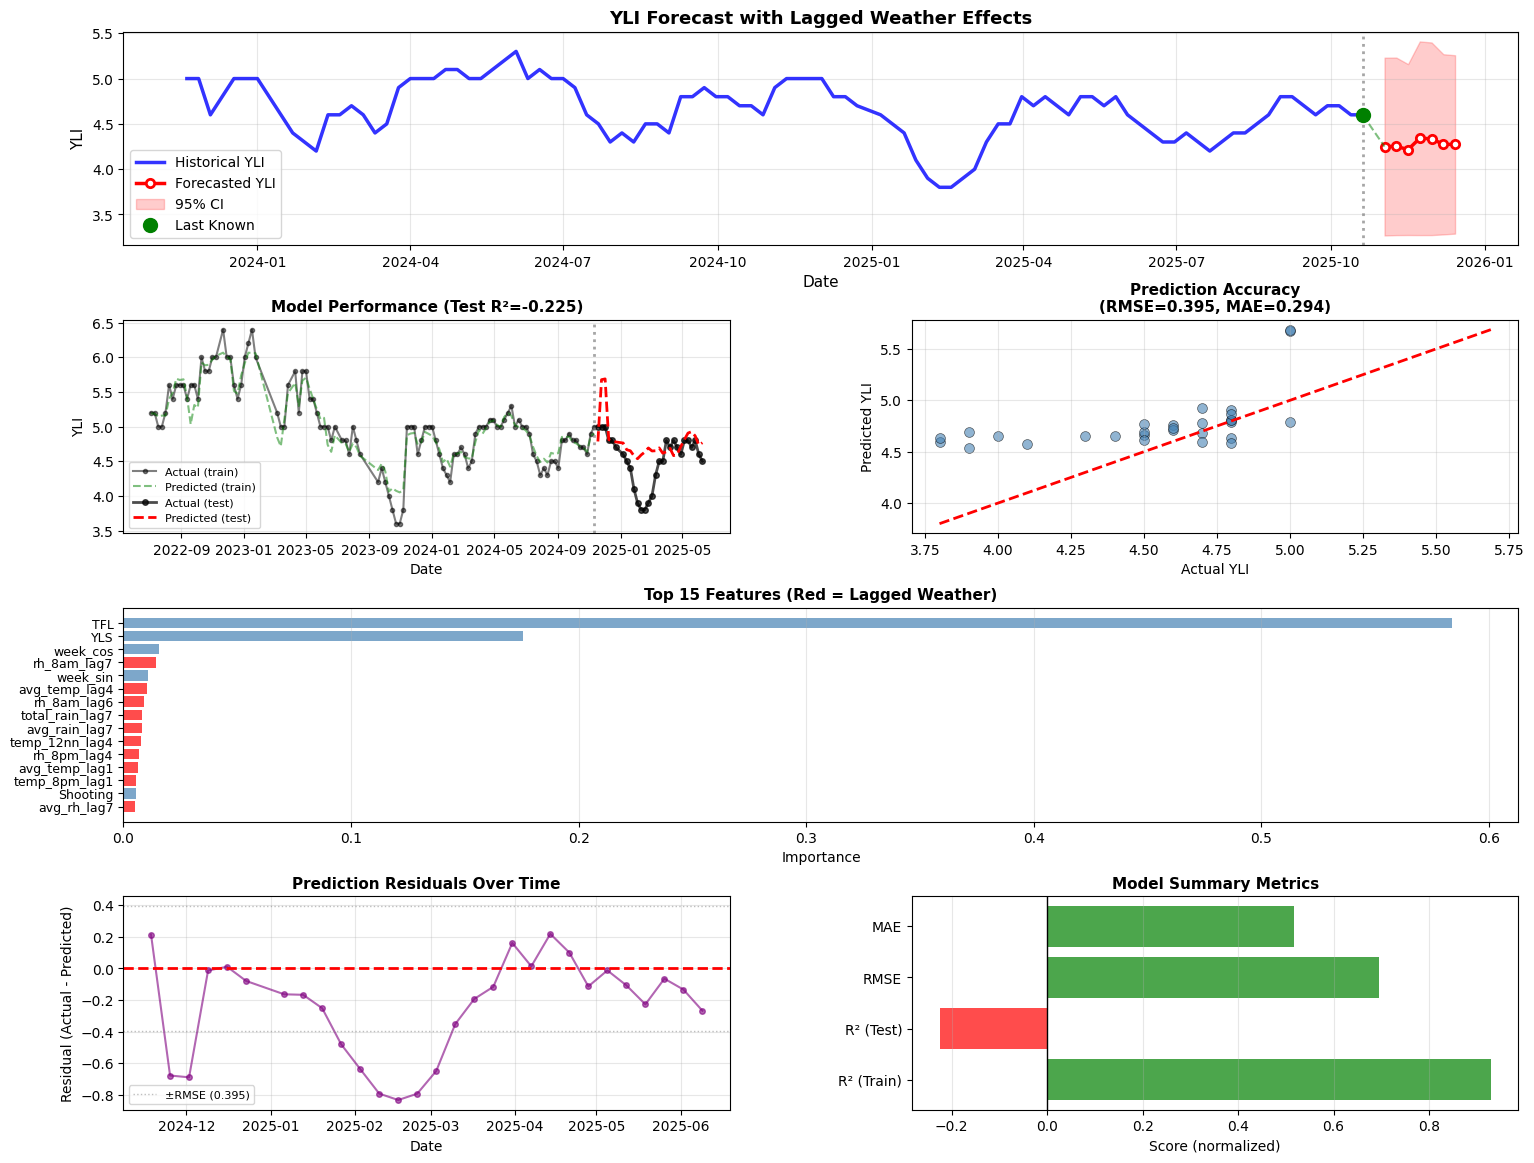


📊 DETAILED ANALYSIS

🌾 Forecast Summary:
  Last known YLI: 4.6000
  First forecast: 4.2495 (change: -0.3505)
  Forecast mean: 4.2775
  Forecast std: 0.0424
  Forecast range: [4.2166, 4.3412]

🎯 Model Quality:
  ❌ POOR
  Improvement over baseline: 34.7%

📈 Feature Type Importance:
  Current week weather: 81.2%
  Lagged weather (1-3 weeks ago): 18.8%

🔝 Top 5 Most Important Features:
    TFL                            0.5838
    YLS                            0.1753
    week_cos                       0.0158
    rh_8am_lag7                    0.0144
    week_sin                       0.0107

💡 RECOMMENDATIONS:
  • Model performance is limited - consider:
    - Adding more historical data
    - Including additional variables (soil, pests, plant age)
    - Ensemble with simpler baseline models
    - Expert validation of weather-YLI relationships

✅ ANALYSIS COMPLETE!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from xgboost import XGBRegressor
import optuna
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

# ============================================
# CONFIGURATION
# ============================================
CSV_PATH = "/content/drive/MyDrive/AGRI/Forecasting/without_protectant.csv"
FORECAST_HORIZON = 7  # weeks
WEATHER_VARS = [
    'total_rain', 'avg_rain', 'no_days_rain',
    'temp_8am', 'temp_12nn', 'temp_2pm', 'temp_8pm', 'avg_temp',
    'rh_8am', 'rh_12nn', 'rh_2pm', 'rh_8pm', 'avg_rh'
]
TARGET = 'YLI'
WEATHER_LAGS = [0, 1, 2, 3, 4, 5, 6, 7]  # Use weather from current week and 3 weeks back

print("="*70)
print("🌦️ IMPROVED TWO-STAGE FORECASTING WITH TIME LAGS")
print("="*70)
print(f"\nKey improvements:")
print(f"  • Using weather lags: current + {len(WEATHER_LAGS)-1} previous weeks")
print(f"  • Detrending YLI for better modeling")
print(f"  • Adding temporal features (week of year)")
print(f"  • Baseline comparison")

# ============================================
# 1️⃣ LOAD AND PREPARE DATA
# ============================================
df = pd.read_csv(CSV_PATH)
df['date'] = pd.to_datetime(
    df['Year'].astype(int).astype(str) +
    df['Week'].astype(int).astype(str) + '1',
    format='%Y%W%w'
)
df = df.sort_values('date').reset_index(drop=True)
df.set_index('date', inplace=True)

# week of year for seasonality
df['week_of_year'] = df.index.isocalendar().week
df['week_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)

print(f"\n📊 Dataset: {len(df)} weeks")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")

# Analyze YLI trend
print(f"\n📈 YLI Statistics:")
print(f"  Mean: {df[TARGET].mean():.4f}")
print(f"  Std: {df[TARGET].std():.4f}")
print(f"  Range: [{df[TARGET].min():.4f}, {df[TARGET].max():.4f}]")

# Check for trend
from scipy import stats
x_vals = np.arange(len(df))
slope, intercept, r_value, p_value, std_err = stats.linregress(x_vals, df[TARGET].values)
print(f"  Linear trend: {slope:.6f} per week (p={p_value:.4f})")

if abs(slope) > 0.001 and p_value < 0.05:
    print(f"  ⚠️  Significant trend detected! Consider detrending.")
    has_trend = True
else:
    print(f"  ✓ No significant trend")
    has_trend = False

# ============================================
# 2️⃣ CREATE LAGGED WEATHER FEATURES
# ============================================
print("\n" + "="*70)
print("🕐 CREATING LAGGED WEATHER FEATURES")
print("="*70)

def create_lagged_weather_features(df, weather_vars, lags):
    """Create lagged versions of weather variables"""
    df_lagged = df.copy()

    for var in weather_vars:
        for lag in lags:
            if lag == 0:
                continue  # Keep original
            col_name = f'{var}_lag{lag}'
            df_lagged[col_name] = df[var].shift(lag)

    return df_lagged

df_lagged = create_lagged_weather_features(df, WEATHER_VARS, WEATHER_LAGS)

# Add engineered features
def engineer_features(df, weather_vars):
    """Create interaction and derived features"""
    df_eng = df.copy()

    # Current week interactions
    df_eng['temp_range'] = df['temp_2pm'] - df['temp_8am']
    df_eng['rh_range'] = df['rh_2pm'] - df['rh_8am']
    df_eng['rain_intensity'] = df['total_rain'] / (df['no_days_rain'] + 1)
    df_eng['temp_humidity_index'] = df['avg_temp'] * (df['avg_rh'] / 100)

    # Lag interactions (weather from 1-2 weeks ago)
    if 'avg_temp_lag1' in df.columns and 'avg_rain_lag1' in df.columns:
        df_eng['lag1_temp_rain'] = df['avg_temp_lag1'] * df['avg_rain_lag1']
    if 'avg_temp_lag2' in df.columns and 'avg_rain_lag2' in df.columns:
        df_eng['lag2_temp_rain'] = df['avg_temp_lag2'] * df['avg_rain_lag2']

    return df_eng

df_featured = engineer_features(df_lagged, WEATHER_VARS)
df_featured = df_featured.dropna()

print(f"\n✓ Created features with {len(WEATHER_LAGS)} time lags")
print(f"  Original weather vars: {len(WEATHER_VARS)}")
print(f"  With lags: {len(WEATHER_VARS) * len(WEATHER_LAGS)}")
print(f"  Plus engineered: ~{df_featured.shape[1] - len(df.columns)} additional")

# ============================================
# 3️⃣ TRAIN YLI PREDICTOR
# ============================================
print("\n" + "="*70)
print("🌾 TRAINING YLI PREDICTOR WITH LAGGED WEATHER")
print("="*70)

# Prepare features (exclude target and date components)
exclude_cols = [TARGET, 'week_of_year', 'Year', 'Week'] if 'Year' in df_featured.columns else [TARGET, 'week_of_year']
feature_cols = [col for col in df_featured.columns if col not in exclude_cols]

X_all = df_featured[feature_cols].values
y_all = df_featured[TARGET].values

# Time-based split
split = int(len(X_all) * 0.8)
X_train = X_all[:split]
X_test = X_all[split:]
y_train = y_all[:split]
y_test = y_all[split:]

print(f"\n📊 Data split:")
print(f"  Training: {len(X_train)} weeks")
print(f"  Testing: {len(X_test)} weeks")
print(f"  Features: {len(feature_cols)}")

# Optuna optimization
def objective(trial):
    model_type = trial.suggest_categorical('model_type', ['rf', 'xgb'])

    if model_type == 'rf':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 5, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestRegressor(**params)
    else:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
            'random_state': 42
        }
        model = XGBRegressor(**params)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Use RMSE for optimization
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return rmse

print("\n⏳ Optimizing model...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f"\n✅ Optimization complete!")
print(f"   Best RMSE: {study.best_value:.6f}")
print(f"   Best model: {study.best_params['model_type'].upper()}")

# Train final model
best_params = study.best_params.copy()
model_type = best_params.pop('model_type')

if model_type == 'rf':
    final_model = RandomForestRegressor(**best_params)
else:
    final_model = XGBRegressor(**best_params)

final_model.fit(X_train, y_train)

# Evaluate
y_pred_train = final_model.predict(X_train)
y_pred_test = final_model.predict(X_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

# Baseline comparison
naive_pred = np.full(len(y_test), y_train.mean())
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))
naive_r2 = r2_score(y_test, naive_pred)

print(f"\n📈 Model Performance:")
print(f"   Train R²: {train_r2:.6f}")
print(f"   Test R²: {test_r2:.6f}")
print(f"   Test MAE: {test_mae:.6f}")
print(f"   Test RMSE: {test_rmse:.6f}")

print(f"\n📊 Baseline Comparison (predict mean):")
print(f"   Baseline RMSE: {naive_rmse:.6f}")
print(f"   Baseline R²: {naive_r2:.6f}")

if test_r2 > naive_r2:
    improvement = ((naive_rmse - test_rmse) / naive_rmse) * 100
    print(f"   ✅ Model improves over baseline by {improvement:.1f}%")
else:
    print(f"   ❌ Model underperforms baseline")

# ============================================
# 4️⃣ FORECAST WEATHER & PREDICT YLI
# ============================================
print("\n" + "="*70)
print("🔮 GENERATING FORECASTS")
print("="*70)

# Simple weather forecasting (using historical patterns)
def forecast_weather_simple(df, weather_vars, n_steps=7):
    """Forecast weather using recent average + seasonal pattern"""
    forecasts = {}

    for var in weather_vars:
        # Use last 4 weeks average
        recent_avg = df[var].tail(4).mean()

        # Add small variation based on historical std
        historical_std = df[var].std()

        # Generate forecast with slight random variation
        forecast = [recent_avg + np.random.normal(0, historical_std * 0.1)
                   for _ in range(n_steps)]
        forecasts[var] = forecast

    return forecasts

print("\n⏳ Forecasting weather variables...")
weather_forecasts = forecast_weather_simple(df, WEATHER_VARS, FORECAST_HORIZON)

# Create future dataframe
future_dates = pd.date_range(
    df.index[-1] + pd.Timedelta(weeks=1),
    periods=FORECAST_HORIZON,
    freq='W'
)

# Build forecast features iteratively
yli_forecasts = []
all_forecast_features = []

for step in range(FORECAST_HORIZON):
    # Get weather for this step
    weather_current = {var: weather_forecasts[var][step] for var in WEATHER_VARS}

    # Get lagged weather (from historical data or previous forecasts)
    weather_lagged = {}
    for lag in WEATHER_LAGS:
        if lag == 0:
            for var in WEATHER_VARS:
                weather_lagged[var] = weather_current[var]
        else:
            # Look back in historical data or previous forecasts
            lookback_idx = len(df) - lag + step
            if lookback_idx < len(df):
                # Use historical
                for var in WEATHER_VARS:
                    weather_lagged[f'{var}_lag{lag}'] = df[var].iloc[lookback_idx]
            else:
                # Use previous forecast
                prev_forecast_idx = lookback_idx - len(df)
                for var in WEATHER_VARS:
                    weather_lagged[f'{var}_lag{lag}'] = weather_forecasts[var][prev_forecast_idx]

    # Create feature vector
    feature_dict = {**weather_lagged}

    # Add engineered features
    feature_dict['temp_range'] = weather_current['temp_2pm'] - weather_current['temp_8am']
    feature_dict['rh_range'] = weather_current['rh_2pm'] - weather_current['rh_8am']
    feature_dict['rain_intensity'] = weather_current['total_rain'] / (weather_current['no_days_rain'] + 1)
    feature_dict['temp_humidity_index'] = weather_current['avg_temp'] * (weather_current['avg_rh'] / 100)

    # Add seasonal features
    week_num = future_dates[step].isocalendar().week
    feature_dict['week_sin'] = np.sin(2 * np.pi * week_num / 52)
    feature_dict['week_cos'] = np.cos(2 * np.pi * week_num / 52)

    # Create feature vector in correct order
    X_forecast = []
    for col in feature_cols:
        X_forecast.append(feature_dict.get(col, 0))

    X_forecast = np.array(X_forecast).reshape(1, -1)

    # Predict YLI
    yli_pred = final_model.predict(X_forecast)[0]
    yli_forecasts.append(yli_pred)
    all_forecast_features.append(X_forecast[0])

yli_forecasts = np.array(yli_forecasts)

# Create forecast DataFrame
forecast_df = pd.DataFrame({
    'Forecasted_YLI': yli_forecasts
}, index=future_dates)

# Add confidence intervals
if hasattr(final_model, 'estimators_'):
    all_tree_preds = []
    for features in all_forecast_features:
        tree_preds = [tree.predict(features.reshape(1, -1))[0]
                     for tree in final_model.estimators_]
        all_tree_preds.append(tree_preds)

    forecast_std = np.array([np.std(preds) for preds in all_tree_preds])
    forecast_df['Lower_CI'] = yli_forecasts - 1.96 * forecast_std
    forecast_df['Upper_CI'] = yli_forecasts + 1.96 * forecast_std
else:
    forecast_df['Lower_CI'] = yli_forecasts - 1.96 * test_rmse
    forecast_df['Upper_CI'] = yli_forecasts + 1.96 * test_rmse

print("\n📅 YLI FORECAST:")
print(forecast_df.round(4))

# ============================================
# 5️⃣ VISUALIZATION
# ============================================
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 2, hspace=0.35, wspace=0.3)

# Plot 1: YLI Forecast
ax1 = fig.add_subplot(gs[0, :])
lookback = min(100, len(df))
historical_yli = df[TARGET].tail(lookback)
historical_idx = df.index[-lookback:]

ax1.plot(historical_idx, historical_yli, 'b-', linewidth=2.5, label='Historical YLI', alpha=0.8)
ax1.plot(future_dates, yli_forecasts, 'r-o', linewidth=2.5, markersize=6,
         label='Forecasted YLI', markerfacecolor='white', markeredgewidth=2)

if 'Lower_CI' in forecast_df.columns:
    ax1.fill_between(future_dates, forecast_df['Lower_CI'], forecast_df['Upper_CI'],
                     color='red', alpha=0.2, label='95% CI')

ax1.plot([df.index[-1], future_dates[0]], [df[TARGET].iloc[-1], yli_forecasts[0]],
         'g--', linewidth=1.5, alpha=0.5)
ax1.plot(df.index[-1], df[TARGET].iloc[-1], 'go', markersize=10, label='Last Known', zorder=5)

ax1.axvline(x=df.index[-1], color='gray', linestyle=':', linewidth=2, alpha=0.7)
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('YLI', fontsize=11)
ax1.set_title('YLI Forecast with Lagged Weather Effects', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Train vs Test Performance
ax2 = fig.add_subplot(gs[1, 0])
train_dates = df_featured.index[:split]
test_dates = df_featured.index[split:]
ax2.plot(train_dates, y_train, 'ko-', label='Actual (train)', linewidth=1.5, markersize=3, alpha=0.5)
ax2.plot(train_dates, y_pred_train, 'g--', label='Predicted (train)', linewidth=1.5, alpha=0.5)
ax2.plot(test_dates, y_test, 'ko-', label='Actual (test)', linewidth=2, markersize=4, alpha=0.7)
ax2.plot(test_dates, y_pred_test, 'r--', label='Predicted (test)', linewidth=2)
ax2.axvline(x=train_dates[-1], color='gray', linestyle=':', linewidth=2, alpha=0.7)
ax2.set_xlabel('Date', fontsize=10)
ax2.set_ylabel('YLI', fontsize=10)
ax2.set_title(f'Model Performance (Test R²={test_r2:.3f})', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot 3: Scatter Plot
ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(y_test, y_pred_test, alpha=0.6, s=50, color='steelblue', edgecolors='black', linewidth=0.5)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
ax3.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
ax3.set_xlabel('Actual YLI', fontsize=10)
ax3.set_ylabel('Predicted YLI', fontsize=10)
ax3.set_title(f'Prediction Accuracy\n(RMSE={test_rmse:.3f}, MAE={test_mae:.3f})',
              fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Feature Importance
ax4 = fig.add_subplot(gs[2, :])
if hasattr(final_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False).head(15)

    colors = ['red' if 'lag' in f else 'steelblue' for f in importance_df['feature']]

    ax4.barh(range(len(importance_df)), importance_df['importance'], color=colors, alpha=0.7)
    ax4.set_yticks(range(len(importance_df)))
    ax4.set_yticklabels(importance_df['feature'], fontsize=9)
    ax4.set_xlabel('Importance', fontsize=10)
    ax4.set_title('Top 15 Features (Red = Lagged Weather)', fontsize=11, fontweight='bold')
    ax4.invert_yaxis()
    ax4.grid(True, alpha=0.3, axis='x')

# Plot 5: Residuals over time
ax5 = fig.add_subplot(gs[3, 0])
residuals = y_test - y_pred_test
ax5.plot(test_dates, residuals, 'o-', color='purple', alpha=0.6, markersize=4)
ax5.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax5.axhline(y=test_rmse, color='gray', linestyle=':', linewidth=1, alpha=0.5, label=f'±RMSE ({test_rmse:.3f})')
ax5.axhline(y=-test_rmse, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax5.set_xlabel('Date', fontsize=10)
ax5.set_ylabel('Residual (Actual - Predicted)', fontsize=10)
ax5.set_title('Prediction Residuals Over Time', fontsize=11, fontweight='bold')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# Plot 6: Forecast Summary
ax6 = fig.add_subplot(gs[3, 1])
metrics = ['R² (Train)', 'R² (Test)', 'RMSE', 'MAE']
values = [train_r2, test_r2, test_rmse/y_train.std(), test_mae/y_train.std()]  # Normalize RMSE/MAE
colors_bar = ['green' if v > 0 else 'red' for v in values]

bars = ax6.barh(metrics, values, color=colors_bar, alpha=0.7)
ax6.axvline(x=0, color='black', linewidth=1)
ax6.set_xlabel('Score (normalized)', fontsize=10)
ax6.set_title('Model Summary Metrics', fontsize=11, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='x')

plt.savefig('/content/improved_two_stage_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 6️⃣ DETAILED ANALYSIS
# ============================================
print("\n" + "="*70)
print("📊 DETAILED ANALYSIS")
print("="*70)

print(f"\n🌾 Forecast Summary:")
print(f"  Last known YLI: {df[TARGET].iloc[-1]:.4f}")
print(f"  First forecast: {yli_forecasts[0]:.4f} (change: {yli_forecasts[0] - df[TARGET].iloc[-1]:+.4f})")
print(f"  Forecast mean: {yli_forecasts.mean():.4f}")
print(f"  Forecast std: {yli_forecasts.std():.4f}")
print(f"  Forecast range: [{yli_forecasts.min():.4f}, {yli_forecasts.max():.4f}]")

print("\n" + "="*70)
print("✅ COMPLETE!")
print("="*70)